In [3]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import os

from torchvision import transforms
from sklearn.preprocessing import normalize
from PIL import Image
from tqdm import tqdm
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [4]:
def load_dino_v2(dino_v2):
    #dino_v2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
    models = {}
    for key, value in dino_v2.items():
        models[key] = torch.hub.load('facebookresearch/dinov2', value)
        models[key] = models[key].to(device)
        models[key].eval()
        print(f"¡Modelo {value} cargado exitosamente!")
        print(f"Dimensión de salida del modelo: {models[key].embed_dim}")
    return models


dino_v2 = {
    'dinov2_vits14':'dinov2_vits14',
    'dinov2_vitb14': 'dinov2_vitb14',
    'dinov2_vitl14':'dinov2_vitl14',
    #'dinov2_vitg14':'dinov2_vitg14'
    }

dino_models_v2 = load_dino_v2(dino_v2)


Using cache found in /home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main
/home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


¡Modelo dinov2_vits14 cargado exitosamente!
Dimensión de salida del modelo: 384


Using cache found in /home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main


¡Modelo dinov2_vitb14 cargado exitosamente!
Dimensión de salida del modelo: 768


Using cache found in /home/mbustamc/.cache/torch/hub/facebookresearch_dinov2_main


¡Modelo dinov2_vitl14 cargado exitosamente!
Dimensión de salida del modelo: 1024


In [5]:
#!gdown --id 1-LqJ2bS_T8XOx5TClDq31MCkPPoXO4bZ
#!unzip dinov3-main.zip



def load_dino_v3(dino_v3):
    models = {}
    for model in dino_v3:
        #!gdown --id {model['descarga']}
        model_name = model['nombre']
        models[model_name] = torch.hub.load(repo_or_dir='./dinov3-main', model=model_name, source='local', weights=model['pesos'])
        models[model_name] = models[model_name].to(device)
        models[model_name].eval()
        print(f"¡Modelo {model_name} cargado exitosamente!")
        print(f"Dimensión de salida del modelo: {models[model_name].embed_dim}")
    return models


dinov3_vits16plus = {
    'nombre':'dinov3_vits16plus',
    'descarga':'1fH2rq53x6JY6zE_WBKH5vP_ZGq4jvj46',
    'pesos':'dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth'
    }

dinov3_vitb16 = {
    'nombre':'dinov3_vitb16',
    'descarga':'1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m',
    'pesos':'dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'
    }


dinov3_vitl16 = {
    'nombre':'dinov3_vitl16',
    'descarga':'1CfyML_a7PkVpt4Lhy-3yNxSfUgsFfgCs',
    'pesos':'dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth'
    }


dino_v3 = [dinov3_vits16plus, dinov3_vitb16,]

dino_models_v3 = load_dino_v3(dino_v3)

dino_models = dino_models_v2 | dino_models_v3

print(f'Keys: {dino_models.keys()}')

¡Modelo dinov3_vits16plus cargado exitosamente!
Dimensión de salida del modelo: 384
¡Modelo dinov3_vitb16 cargado exitosamente!
Dimensión de salida del modelo: 768
Keys: dict_keys(['dinov2_vits14', 'dinov2_vitb14', 'dinov2_vitl14', 'dinov3_vits16plus', 'dinov3_vitb16'])


In [13]:

# Descargar el archivo zip desde Google Drive (DESCOMENTAR SI ES NECESARIO)
#!gdown --id 11-TD6add7zZaukIB8l2cVnBTJgsTjo8n ---

# Descomprimir el archivo (DESCOMENTAR SI ES NECESARIO

#!unzip dataset_ecom_mini.zip

# Cargar los metadatos del conjunto de datos
data_dir = Path('eval')
df = pd.read_csv('eval.csv', delimiter=';')

print(f"El conjunto de datos contiene {len(df)} imágenes")
print(f"\nDistribución de categorías:")
print(df['GlobalCategoryEN'].value_counts())


El conjunto de datos contiene 300 imágenes

Distribución de categorías:
GlobalCategoryEN
Toy Store                  54
Sports                     37
Technology                 35
Home                       35
Pets                       31
Videogames and Consoles    30
Clothes and Shoes          27
Furniture                  13
Babies                     12
Beauty                      8
School                      8
Christmas Decoration        4
Bedroom                     4
Home Appliances             1
Foods and Drinks            1
Name: count, dtype: int64


In [7]:
def transform(image):
    transform_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform_pipeline(image)

def encode_image(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(img_tensor)

    return features.cpu().numpy().flatten()


def generar_embeddings(model, df, data_dir, nombre_modelo):

    embeddings = []
    valid_names = []

    print(f"\n Generando embeddings con {nombre_modelo}...")
    model.eval()
    model.to(device)

    for filename in tqdm(df['Title'].values):
        img_path = data_dir / f"{filename}.jpg"
        if img_path.exists():
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    feat = model(img_tensor)
                embeddings.append(feat.cpu().numpy().flatten())
                valid_names.append(filename)
            except Exception as e:
                print(f"Error con {filename}: {e}")

    embeddings = np.array(embeddings)
    print(f"{len(embeddings)} imágenes procesadas con {nombre_modelo}")
    return embeddings, valid_names



In [8]:
# Función auxiliar para calcular similitud coseno
def cosine_similarity(vec1, vec2):
    """
    vec1, vec2: (numpy arrays)
    Puntuación de similitud entre 0 y 1 (1 = idéntico)
    """
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)



def calcular_similitud(embeddings):
    """
    embeddings: matriz N x D
    Retorna la matriz N x N de similitud coseno.
    """
    embeddings_normalized = normalize(embeddings, axis=1)
    similarity_matrix = np.dot(embeddings_normalized, embeddings_normalized.T)
    return similarity_matrix



def display_image_comparison(img_paths, titles, similarities=None):
    """
    Muestra imágenes lado a lado con sus títulos y puntuaciones de similitud.
    """
    n_images = len(img_paths)
    fig, axes = plt.subplots(1, n_images, figsize=(5*n_images, 5))

    if n_images == 1:
        axes = [axes]

    for idx, (img_path, title) in enumerate(zip(img_paths, titles)):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')

        if similarities is not None and idx > 0:
            axes[idx].set_title(f"{title}\nSimilitud: {similarities[idx-1]:.4f}", fontsize=12)
        else:
            axes[idx].set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()

def procesar_varios_modelos(modelos_dict, df, data_dir):
    """
    modelos_dict: {nombre_modelo: modelo_torch}
    df: dataframe con columna 'Title'
    """
    resultados = {}

    for nombre, modelo in modelos_dict.items():
        emb, valid_names = generar_embeddings(modelo, df, data_dir, nombre)
        sim = calcular_similitud(emb)
        resultados[nombre] = {
            'embeddings': emb,
            'valid_names': valid_names,
            'similarity_matrix': sim
        }
        print(f"{nombre}: embeddings {emb.shape}, matriz {sim.shape}")

    return resultados

In [9]:
resultados_dino = procesar_varios_modelos(dino_models, df, data_dir)


 Generando embeddings con dinov2_vits14...


100%|██████████| 300/300 [00:59<00:00,  5.07it/s]


300 imágenes procesadas con dinov2_vits14
dinov2_vits14: embeddings (300, 384), matriz (300, 300)

 Generando embeddings con dinov2_vitb14...


100%|██████████| 300/300 [02:53<00:00,  1.73it/s]


300 imágenes procesadas con dinov2_vitb14
dinov2_vitb14: embeddings (300, 768), matriz (300, 300)

 Generando embeddings con dinov2_vitl14...


...

300 imágenes procesadas con dinov2_vitl14
dinov2_vitl14: embeddings (300, 1024), matriz (300, 300)

 Generando embeddings con dinov3_vits16plus...


100%|██████████| 300/300 [01:08<00:00,  4.38it/s]


300 imágenes procesadas con dinov3_vits16plus
dinov3_vits16plus: embeddings (300, 384), matriz (300, 300)

 Generando embeddings con dinov3_vitb16...


100%|██████████| 300/300 [01:59<00:00,  2.52it/s]

300 imágenes procesadas con dinov3_vitb16
dinov3_vitb16: embeddings (300, 768), matriz (300, 300)


In [10]:
for model_name, data in resultados_dino.items():
    print(f"\nAnálisis de similitud para el modelo: {model_name}")
    similarity_matrix = data['similarity_matrix']       
    print(f"Forma de la matriz de similitud: {similarity_matrix.shape}")
    diag_vals = similarity_matrix.diagonal()[:5]
    print(f"Valores diagonales (auto-similitud) deberían ser ~1.0: {diag_vals}")
    print(f"\nEstadísticas de similitud:")
    print(f"  Mín:   {similarity_matrix.min():.4f}")
    print(f"  Máx:   {similarity_matrix.max():.4f}")
    print(f"  Media: {similarity_matrix.mean():.4f}")
    print(f"  Desv.: {similarity_matrix.std():.4f}")
    print("=" * 60)




Análisis de similitud para el modelo: dinov2_vits14
Forma de la matriz de similitud: (300, 300)
Valores diagonales (auto-similitud) deberían ser ~1.0: [1.        0.9999999 0.9999999 0.9999999 1.       ]

Estadísticas de similitud:
  Mín:   -0.1963
  Máx:   1.0000
  Media: 0.0607
  Desv.: 0.1130

Análisis de similitud para el modelo: dinov2_vitb14
Forma de la matriz de similitud: (300, 300)
Valores diagonales (auto-similitud) deberían ser ~1.0: [1.0000002  0.99999976 1.0000001  0.9999999  0.9999999 ]

Estadísticas de similitud:
  Mín:   -0.1597
  Máx:   1.0000
  Media: 0.0480
  Desv.: 0.0973

Análisis de similitud para el modelo: dinov2_vitl14
Forma de la matriz de similitud: (300, 300)
Valores diagonales (auto-similitud) deberían ser ~1.0: [1.0000001  1.         0.9999996  0.99999976 1.0000001 ]

Estadísticas de similitud:
  Mín:   -0.1045
  Máx:   1.0000
  Media: 0.0477
  Desv.: 0.0944

Análisis de similitud para el modelo: dinov3_vits16plus
Forma de la matriz de similitud: (300, 300

In [11]:

def find_and_display_top_k_similar(similarity_matrix, query_idx, valid_filenames, data_dir, df, k=10, model_name="modelo"):
    """
    Encuentra y muestra las K imágenes más similares a una imagen de consulta
    usando una matriz de similitud coseno.

    Args:
        similarity_matrix (np.ndarray): Matriz NxN de similitudes coseno.
        query_idx (int): Índice de la imagen de consulta.
        valid_filenames (list[str]): Lista de nombres de archivo (sin extensión).
        data_dir (Path): Carpeta donde están las imágenes.
        df (pd.DataFrame): DataFrame con metadatos (debe contener columna 'Title' y 'GlobalCategoryEN').
        k (int): Número de imágenes similares a mostrar.
        model_name (str): Nombre del modelo usado para calcular similitud.

    Returns:
        dict: Diccionario con índices y similitudes del top K.
    """
    # --- Verificación de entrada ---
    n = similarity_matrix.shape[0]
    if query_idx >= n:
        raise IndexError(f"query_idx={query_idx} fuera de rango (N={n})")

    # --- Calcular similitudes ---
    similarities = similarity_matrix[query_idx]
    top_indices = np.argsort(similarities)[::-1]
    top_indices = [i for i in top_indices if i != query_idx][:k]
    top_similarities = similarities[top_indices]

    # --- Datos de la imagen de consulta ---
    query_filename = valid_filenames[query_idx]
    query_path = data_dir / f"{query_filename}.jpg"
    query_category = df[df["Title"] == query_filename]["GlobalCategoryEN"].values[0]

    print(f"\n=== Modelo: {model_name} ===")
    print(f"Imagen de Consulta: {query_filename} (Categoría: {query_category})")
    print(f"Top {k} imágenes más similares:\n" + "-" * 80)

    for i, (idx, sim) in enumerate(zip(top_indices, top_similarities)):
        fname = valid_filenames[idx]
        cat = df[df["Title"] == fname]["GlobalCategoryEN"].values[0]
        print(f"{i+1:2d}. {fname:25s} | Categoría: {cat:20s} | Similitud: {sim:.4f}")

    # --- Mostrar imágenes ---
    n_cols = 5
    n_rows = (k + n_cols - 1) // n_cols + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten()

    # Imagen de consulta
    query_img = Image.open(query_path)
    axes[0].imshow(query_img)
    axes[0].set_title(f"CONSULTA\n{query_filename}\n{query_category}", fontsize=10, fontweight='bold', color='red')
    axes[0].axis("off")

    for i in range(1, n_cols):
        axes[i].axis("off")

    # Mostrar top K
    for i, (idx, sim) in enumerate(zip(top_indices, top_similarities)):
        fname = valid_filenames[idx]
        img_path = data_dir / f"{fname}.jpg"
        category = df[df["Title"] == fname]["GlobalCategoryEN"].values[0]

        img = Image.open(img_path)
        ax_idx = n_cols + i
        axes[ax_idx].imshow(img)
        axes[ax_idx].set_title(f"#{i+1}: {fname}\n{category}\nSim: {sim:.4f}", fontsize=9)
        axes[ax_idx].axis("off")

    # Ocultar subplots no usados
    for i in range(n_cols + k, len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"Modelo: {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "query_idx": query_idx,
        "top_indices": top_indices,
        "similarities": top_similarities.tolist()
    }


--- Análisis con el modelo: dinov2_vits14 ---

=== Modelo: dinov2_vits14 ===
Imagen de Consulta: im.mk532h.input (Categoría: Home)
Top 5 imágenes más similares:
--------------------------------------------------------------------------------
 1. im.d3fhhz.input           | Categoría: Beauty               | Similitud: 0.4256
 2. im.n4796j.input           | Categoría: Home                 | Similitud: 0.3733
 3. im.cjux4v.input           | Categoría: Beauty               | Similitud: 0.3425
 4. im.tcace4.input           | Categoría: Home                 | Similitud: 0.2811
 5. im.nkwj8a.input           | Categoría: Home                 | Similitud: 0.2717


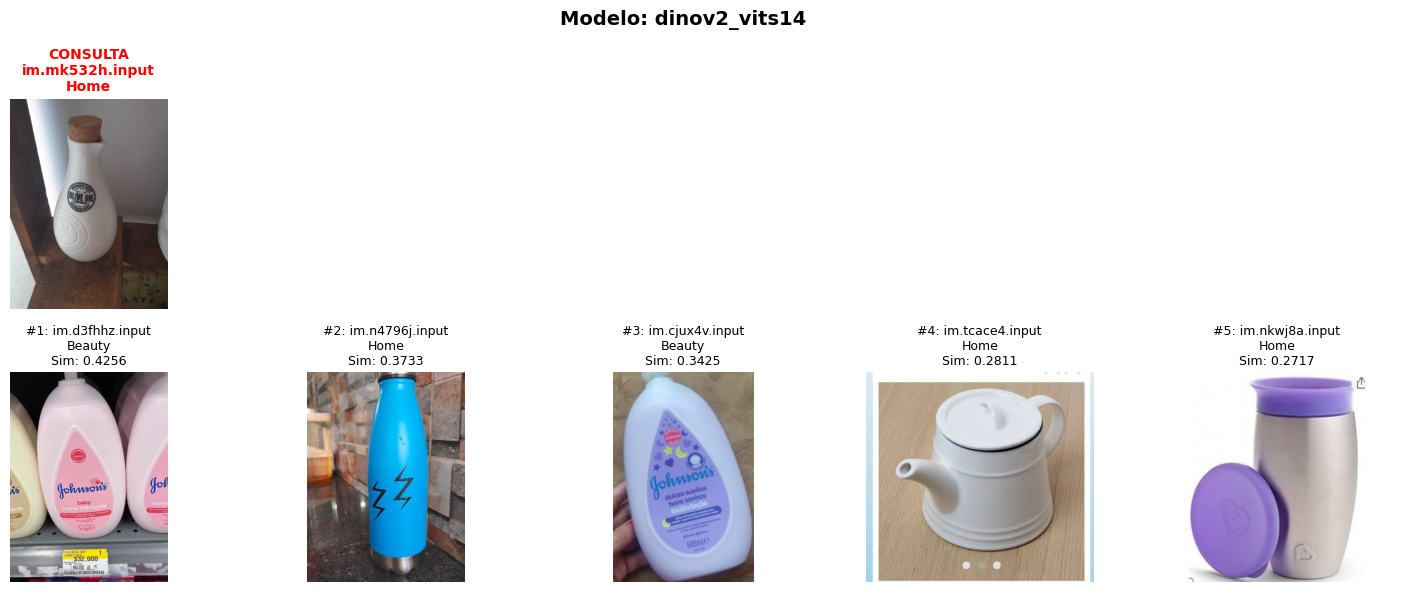


--- Análisis con el modelo: dinov2_vitb14 ---

=== Modelo: dinov2_vitb14 ===
Imagen de Consulta: im.mk532h.input (Categoría: Home)
Top 5 imágenes más similares:
--------------------------------------------------------------------------------
 1. im.n4796j.input           | Categoría: Home                 | Similitud: 0.2577
 2. im.tcace4.input           | Categoría: Home                 | Similitud: 0.2358
 3. im.d3fhhz.input           | Categoría: Beauty               | Similitud: 0.2142
 4. im.4zijfv.input           | Categoría: Babies               | Similitud: 0.2057
 5. im.8pscsv.input           | Categoría: Home                 | Similitud: 0.1867


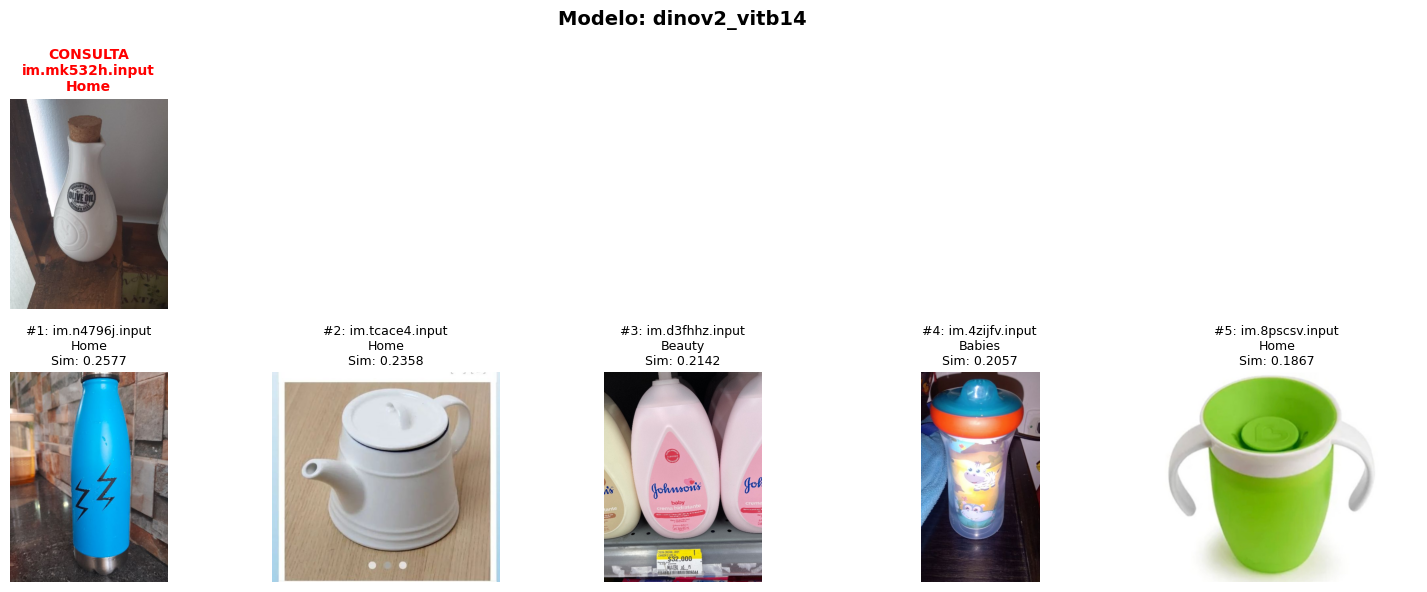


--- Análisis con el modelo: dinov2_vitl14 ---

=== Modelo: dinov2_vitl14 ===
Imagen de Consulta: im.mk532h.input (Categoría: Home)
Top 5 imágenes más similares:
--------------------------------------------------------------------------------
 1. im.tcace4.input           | Categoría: Home                 | Similitud: 0.2598
 2. im.n4796j.input           | Categoría: Home                 | Similitud: 0.2539
 3. im.d3fhhz.input           | Categoría: Beauty               | Similitud: 0.2269
 4. im.cjux4v.input           | Categoría: Beauty               | Similitud: 0.1862
 5. im.mgzj5f.input           | Categoría: Toy Store            | Similitud: 0.1660


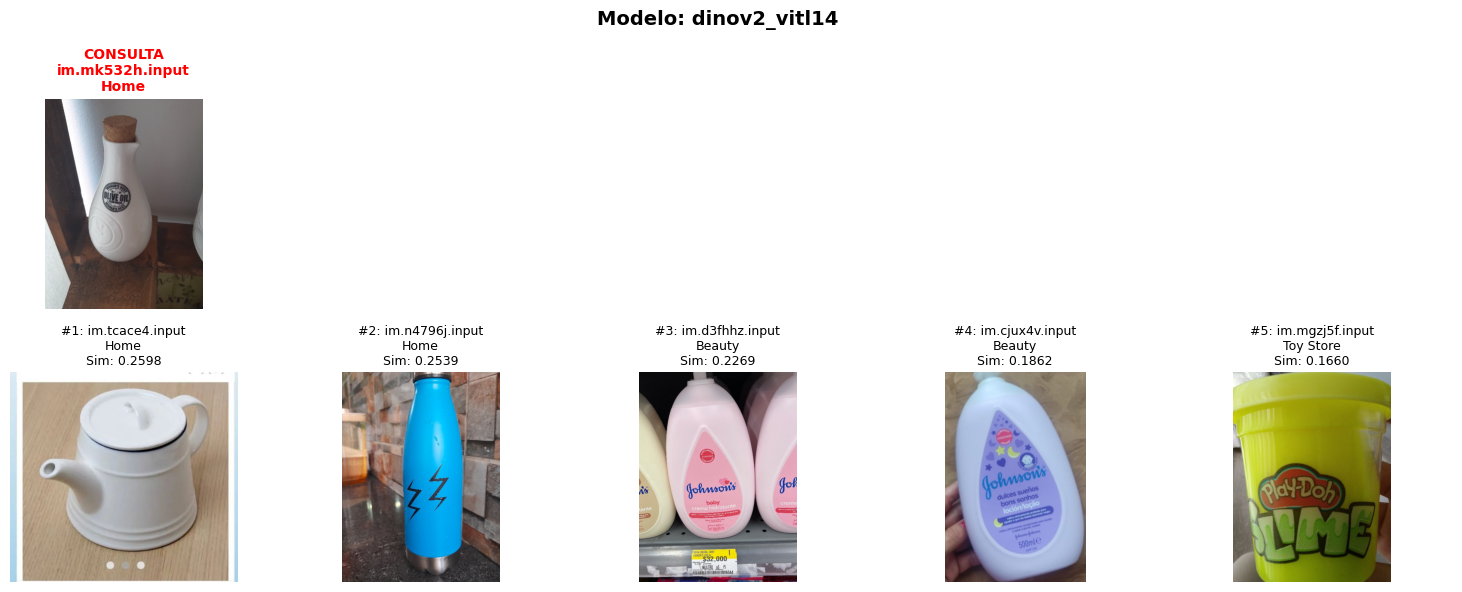


--- Análisis con el modelo: dinov3_vits16plus ---

=== Modelo: dinov3_vits16plus ===
Imagen de Consulta: im.mk532h.input (Categoría: Home)
Top 5 imágenes más similares:
--------------------------------------------------------------------------------
 1. im.d3fhhz.input           | Categoría: Beauty               | Similitud: 0.3600
 2. im.cjux4v.input           | Categoría: Beauty               | Similitud: 0.3071
 3. im.tcace4.input           | Categoría: Home                 | Similitud: 0.2903
 4. im.n4796j.input           | Categoría: Home                 | Similitud: 0.2902
 5. im.ja6ge2.input           | Categoría: Home                 | Similitud: 0.2542


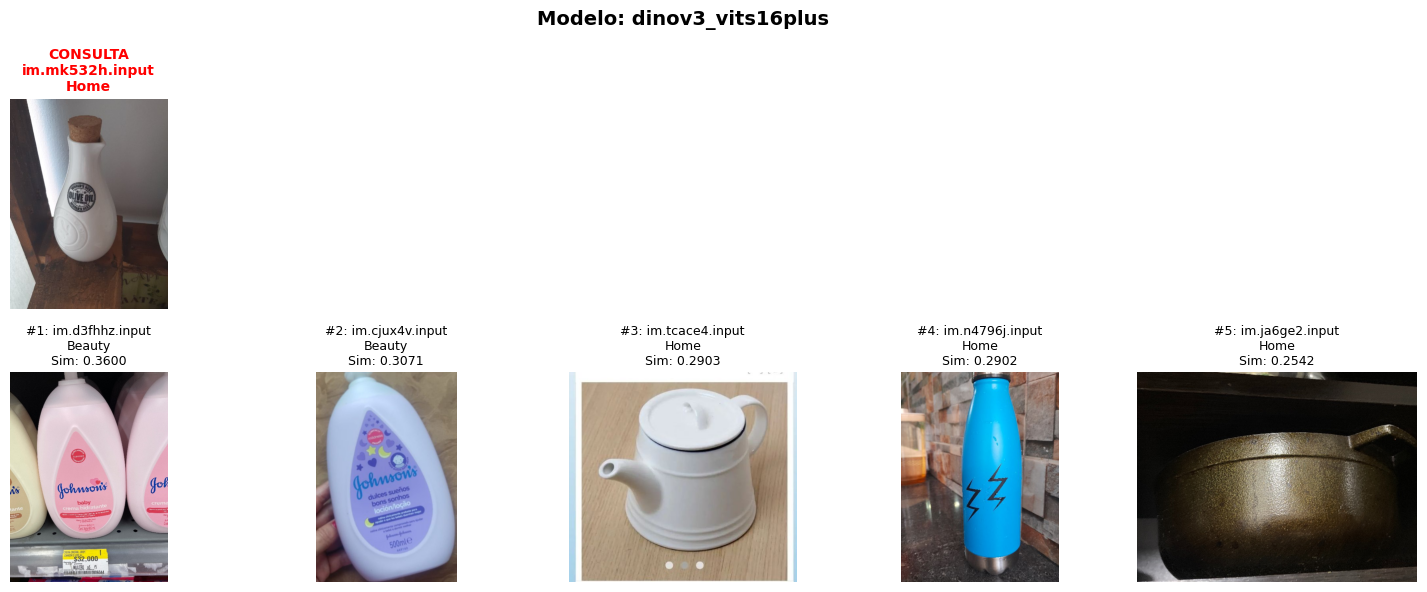


--- Análisis con el modelo: dinov3_vitb16 ---

=== Modelo: dinov3_vitb16 ===
Imagen de Consulta: im.mk532h.input (Categoría: Home)
Top 5 imágenes más similares:
--------------------------------------------------------------------------------
 1. im.d3fhhz.input           | Categoría: Beauty               | Similitud: 0.2502
 2. im.cjux4v.input           | Categoría: Beauty               | Similitud: 0.2237
 3. im.tcace4.input           | Categoría: Home                 | Similitud: 0.2206
 4. im.n4796j.input           | Categoría: Home                 | Similitud: 0.2112
 5. im.egc3ve.input           | Categoría: Home                 | Similitud: 0.1863


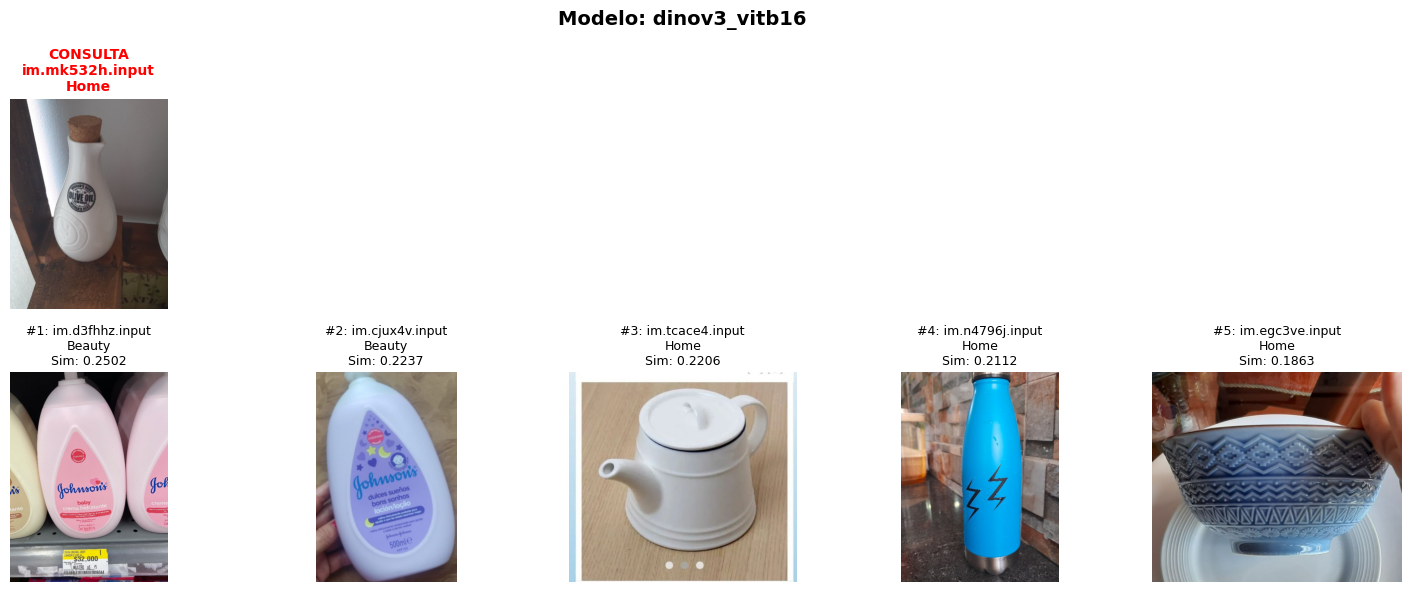

In [16]:
random_idx = random.randint(0, len(df['Title']) - 1)

for key, values in dino_models.items():
    print(f"\n--- Análisis con el modelo: {key} ---")
    similarity_matrix = resultados_dino[key]['similarity_matrix']
    valid_filenames = resultados_dino[key]['valid_names']

    # Seleccionar una imagen de consulta aleatoria
    # random_idx = random.randint(0, len(valid_filenames) - 1)
    find_and_display_top_k_similar(similarity_matrix, random_idx, valid_filenames, data_dir, df, k=5, model_name=key)
    

In [17]:
def compute_average_precision(query_idx, similarity_matrix, valid_filenames, df, k=None):
    """
    Calcula la Precisión Promedio (AP) para una sola consulta.

    Args:
        query_idx: índice de la imagen de consulta.
        similarity_matrix: matriz N x N de similitudes.
        valid_filenames: lista de nombres válidos (en el mismo orden que similarity_matrix).
        df: DataFrame original con 'Title' y 'GlobalCategoryEN'.
        k: número de resultados top a considerar (None = todos los resultados).

    Returns:
        average_precision (float), num_relevant (int)
    """
    # --- Categoría de la consulta ---
    query_filename = valid_filenames[query_idx]
    query_category = df.loc[df['Title'] == query_filename, 'GlobalCategoryEN'].values[0]

    # --- Categorías de todas las imágenes ---
    categories = [
        df.loc[df['Title'] == fn, 'GlobalCategoryEN'].values[0]
        for fn in valid_filenames
    ]

    # --- Máscara de elementos relevantes ---
    relevant_mask = np.array([cat == query_category for cat in categories])
    relevant_mask[query_idx] = False  # excluir la misma imagen
    num_relevant = relevant_mask.sum()

    if num_relevant == 0:
        return 0.0, 0

    # --- Ordenar por similitud (descendente) ---
    similarities = similarity_matrix[query_idx]
    ranked_indices = np.argsort(similarities)[::-1]

    # Eliminar el índice de la consulta
    ranked_indices = ranked_indices[ranked_indices != query_idx]

    # Limitar a top-K si se solicita
    if k is not None:
        ranked_indices = ranked_indices[:k]

    # --- Calcular AP ---
    precision_sum = 0.0
    num_relevant_seen = 0

    for i, idx in enumerate(ranked_indices):
        if relevant_mask[idx]:
            num_relevant_seen += 1
            precision_at_i = num_relevant_seen / (i + 1)
            precision_sum += precision_at_i

    average_precision = precision_sum / num_relevant
    return average_precision, num_relevant


# ---Calcular Mean Average Precision (MAP) ---
def compute_MAP(similarity_matrix, valid_filenames, df, k=None):
    """
    Calcula la Media de Precisión Promedio (MAP) sobre todas las imágenes de consulta.

    Args:
        similarity_matrix: matriz N x N de similitudes.
        valid_filenames: lista de nombres válidos.
        df: DataFrame con columnas 'Title' y 'GlobalCategoryEN'.
        k: número de resultados top a considerar (None = todos los resultados).

    Returns:
        mean_ap: precisión promedio global
        per_image_ap: lista con el AP individual de cada imagen
    """
    aps = []
    total_relevant = 0

    for i in range(len(valid_filenames)):
        ap, n_rel = compute_average_precision(i, similarity_matrix, valid_filenames, df, k)
        aps.append(ap)
        total_relevant += n_rel

    mean_ap = np.mean(aps)
    #print(f"MAP@{k if k else 'all'} = {mean_ap:.4f}  (promedio sobre {len(valid_filenames)} consultas)")
    return mean_ap, aps


# --- Ejemplo de uso con tus resultados ---
# Supongamos que ya tienes tus embeddings y similitud para cada modelo:
# resultados = procesar_varios_modelos(modelos_dict, df, data_dir)

for nombre, res in resultados_dino.items():
    for variable in [10,20,50,100,200,300]:
        sim = res['similarity_matrix']
        valid_names = res['valid_names']
        mean_ap, _ = compute_MAP(sim, valid_names, df, k=variable)
        print(f"MAP@{variable} para {nombre}: {mean_ap:.4f}")

MAP@10 para dinov2_vits14: 0.1611
MAP@20 para dinov2_vits14: 0.2095
MAP@50 para dinov2_vits14: 0.2601
MAP@100 para dinov2_vits14: 0.2963
MAP@200 para dinov2_vits14: 0.3327
MAP@300 para dinov2_vits14: 0.3547
MAP@10 para dinov2_vitb14: 0.1770
MAP@20 para dinov2_vitb14: 0.2265
MAP@50 para dinov2_vitb14: 0.2826
MAP@100 para dinov2_vitb14: 0.3217
MAP@200 para dinov2_vitb14: 0.3576
MAP@300 para dinov2_vitb14: 0.3782
MAP@10 para dinov2_vitl14: 0.1903
MAP@20 para dinov2_vitl14: 0.2526
MAP@50 para dinov2_vitl14: 0.3141
MAP@100 para dinov2_vitl14: 0.3519
MAP@200 para dinov2_vitl14: 0.3880
MAP@300 para dinov2_vitl14: 0.4068
MAP@10 para dinov3_vits16plus: 0.1646
MAP@20 para dinov3_vits16plus: 0.2062
MAP@50 para dinov3_vits16plus: 0.2529
MAP@100 para dinov3_vits16plus: 0.2898
MAP@200 para dinov3_vits16plus: 0.3293
MAP@300 para dinov3_vits16plus: 0.3503
MAP@10 para dinov3_vitb16: 0.1826
MAP@20 para dinov3_vitb16: 0.2387
MAP@50 para dinov3_vitb16: 0.2967
MAP@100 para dinov3_vitb16: 0.3373
MAP@200 par

In [45]:
def calculate_category_map_compact(resultados_dino, df, valid_filenames, k=100):
    """
    Calcula el mAP por categoría para varios modelos basados en similitud ya precalculada.
    """
    results = {}

    for model_name, model_data in resultados_dino.items():
        sim_matrix = model_data['similarity_matrix']
        valid_names = model_data['valid_names']

        unique_categories = sorted(set(df['GlobalCategoryEN']))
        category_map = {}

        for category in unique_categories:
            # Índices de las imágenes de esta categoría
            category_indices = [
                i for i, fn in enumerate(valid_names)
                if df.loc[df['Title'] == fn, 'GlobalCategoryEN'].values[0] == category
            ]

            ap_scores = []
            for idx in category_indices:
                ap, _ = compute_average_precision(idx, sim_matrix, valid_names, df, k)
                ap_scores.append(ap)

            category_map[category] = np.mean(ap_scores) if ap_scores else 0.0

        results[model_name] = category_map

    return results

resultados = calculate_category_map_compact(resultados_dino, df, df['Title'], k=100)

def plot_single_image_precision_recall(models_dict, query_idx, df, resultados_dino, k=100):
    """
    Traza curvas Precision-Recall para una imagen de consulta específica
    usando varios modelos.

    Args:
        models_dict (dict): {nombre_modelo: modelo_torch}
        query_idx (int): índice de la imagen de consulta
        df (DataFrame): metadatos (debe contener 'Title' y 'GlobalCategoryEN')
        resultados_dino (dict): resultados con 'embeddings', 'similarity_matrix' y 'valid_names'
        k (int): número de resultados top a considerar
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    for model_name in models_dict.keys():
        sim_matrix = resultados_dino[model_name]['similarity_matrix']
        valid_names = resultados_dino[model_name]['valid_names']

        query_filename = valid_names[query_idx]
        query_category = df.loc[df['Title'] == query_filename, 'GlobalCategoryEN'].values[0]

        # Categorías de todas las imágenes
        categories = df.set_index('Title').loc[valid_names, 'GlobalCategoryEN'].values
        relevant_mask = (categories == query_category)
        relevant_mask[query_idx] = False  # excluir la misma imagen

        if relevant_mask.sum() == 0:
            print(f"[{model_name}] No hay imágenes relevantes para {query_filename}.")
            continue

        # Ranking por similitud
        ranked_indices = np.argsort(sim_matrix[query_idx])[::-1]
        ranked_indices = ranked_indices[ranked_indices != query_idx][:k]

        # Calcular Precision y Recall
        relevant_seen = np.cumsum(relevant_mask[ranked_indices])
        total_relevant = relevant_mask.sum()
        precisions = relevant_seen / np.arange(1, len(ranked_indices) + 1)
        recalls = relevant_seen / total_relevant

        # AP (si tienes una función ya definida)
        ap, _ = compute_average_precision(query_idx, sim_matrix, valid_names, df, k)
        ax.plot(recalls, precisions, lw=2, label=f"{model_name} (AP={ap:.3f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Precision-Recall — Imagen: {df.iloc[query_idx]['Title']}")

    plt.tight_layout()
    plt.show()


In [44]:
def print_markdown_comparison(results_dict, title="Comparación de Modelos por Categoría (MAP@100)"):
    """
    Imprime una tabla markdown con la comparación de modelos por categoría.
    
    Args:
        results_dict (dict): Diccionario con los resultados de cada modelo
        title (str): Título de la tabla
    """
    
    # Obtener todas las categorías únicas (ordenadas alfabéticamente)
    all_categories = set()
    for model_results in results_dict.values():
        all_categories.update(model_results.keys())
    categories = sorted(all_categories)
    
    # Obtener nombres de modelos
    model_names = list(results_dict.keys())
    
    # Imprimir encabezado
    print(f"# {title}\n")
    
    # Imprimir encabezado de la tabla
    header = "| Categoría | " + " | ".join(model_names) + " |"
    separator = "|-----------|" + "|".join(["-----------" for _ in model_names]) + "|"
    
    print(header)
    print(separator)

print_markdown_comparison(resultados)

# Comparación de Modelos por Categoría (MAP@100)

| Categoría | dinov2_vits14 | dinov2_vitb14 | dinov2_vitl14 | dinov3_vits16plus | dinov3_vitb16 |
|-----------|-----------|-----------|-----------|-----------|-----------|


Generando análisis Precision–Recall...
1️⃣ Curva general


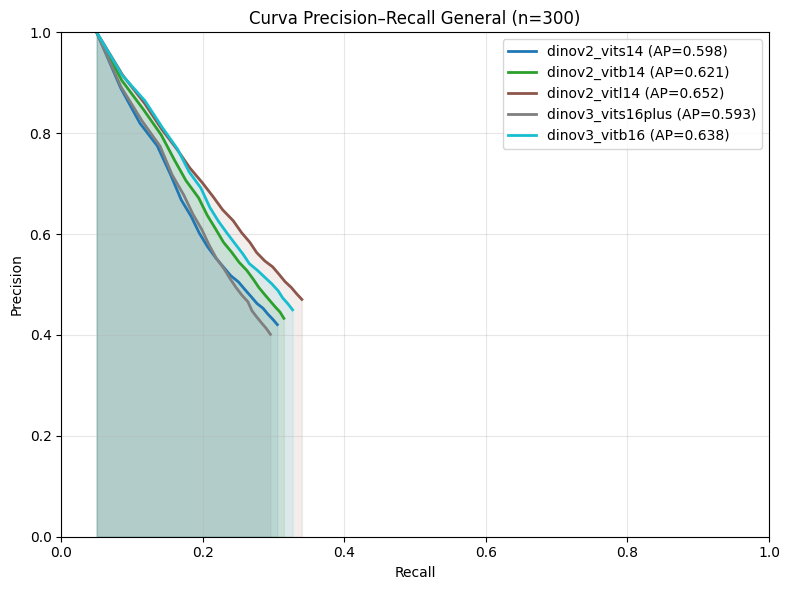

2️⃣ Curvas por categoría


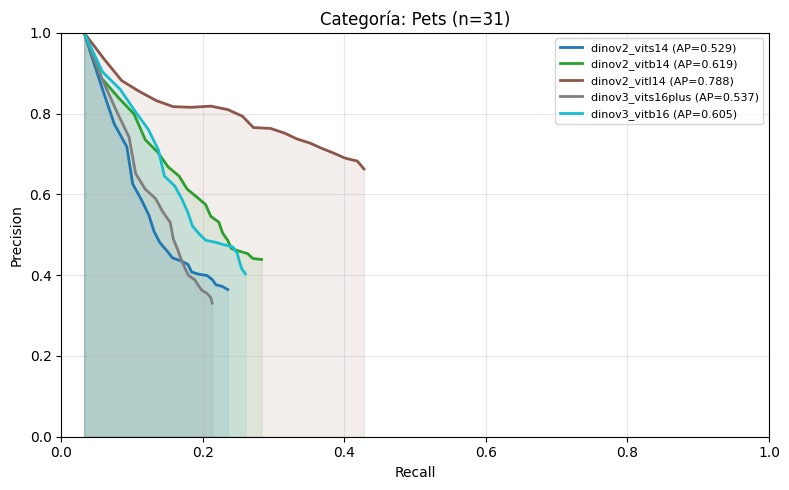

3️⃣ Ejemplo de imagen individual


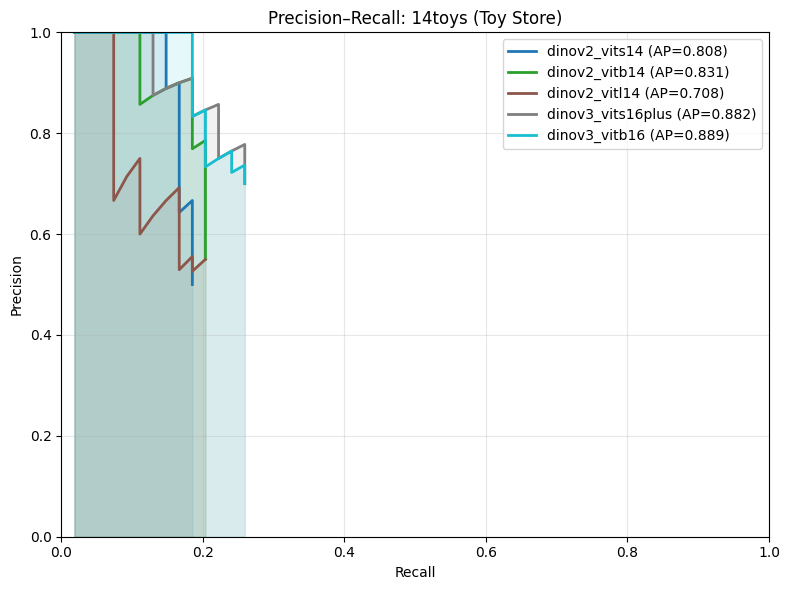

In [46]:
def compute_ap_wrapper(query_idx, sim_matrix, valid_filenames, df, k=20):
    """
    Calcula AP y curvas precisions/recalls usando la matriz de similitud real.
    """
    similarities = sim_matrix[query_idx]  # vector de similitudes para la consulta
    ranked_indices = np.argsort(similarities)[::-1]  # descendente
    ranked_titles = [valid_filenames[i] for i in ranked_indices]

    # Determinar relevancia: 1 si misma categoría, 0 si no
    query_cat = get_category(df, valid_filenames[query_idx])
    relevances = [1 if get_category(df, t) == query_cat else 0 for t in ranked_titles]

    precisions, recalls = [], []
    num_relevant = sum(relevances)
    if num_relevant == 0:
        return 0.0, {'precisions': np.zeros(k), 'recalls': np.zeros(k)}

    tp = 0
    for idx, rel in enumerate(relevances[:k], 1):
        tp += rel
        precisions.append(tp / idx)
        recalls.append(tp / num_relevant)

    ap = np.mean([p for p, r in zip(precisions, recalls) if r > 0])  # aproximación simple

    return ap, {'precisions': np.array(precisions), 'recalls': np.array(recalls)}


# --- Funciones auxiliares ---
def plot_pr_curve(ax, recalls, precisions, model_name, ap, color):
    """Dibuja curva Precision–Recall y relleno."""
    ax.plot(recalls, precisions, label=f"{model_name} (AP={ap:.3f})", color=color, lw=2)
    ax.fill_between(recalls, precisions, alpha=0.1, color=color)

def get_category(df, title):
    """Obtiene la categoría de una imagen según el DataFrame."""
    match = df[df['Title'] == title]
    return match['GlobalCategoryEN'].values[0] if not match.empty else 'Unknown'

def compute_avg_pr(models_dict, df, indices, k):
    """
    Calcula curvas promedio y AP por modelo para un conjunto de índices.
    `models_dict` debe contener funciones que devuelvan (AP, dict con 'precisions' y 'recalls')
    """
    results = {}
    for model_name, compute_ap_function in models_dict.items():
        all_p, all_r, all_ap = [], [], []
        for i in indices:
            ap, res = compute_ap_function(i, k)
            if res and 'precisions' in res and 'recalls' in res:
                all_p.append(res['precisions'])
                all_r.append(res['recalls'])
                all_ap.append(ap)
        if all_p:
            min_len = min(len(p) for p in all_p)
            results[model_name] = {
                'precisions': np.mean([p[:min_len] for p in all_p], axis=0),
                'recalls': np.mean([r[:min_len] for r in all_r], axis=0),
                'ap': np.mean(all_ap)
            }
    return results

# --- Curvas generales ---
def plot_overall_precision_recall(models_dict, df, valid_filenames, k=100):
    fig, ax = plt.subplots(figsize=(8,6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))

    results = compute_avg_pr(models_dict, df, list(range(len(valid_filenames))), k)

    for color, (model_name, data) in zip(colors, results.items()):
        plot_pr_curve(ax, data['recalls'], data['precisions'], model_name, data['ap'], color)

    ax.set(title=f"Curva Precision–Recall General (n={len(valid_filenames)})",
           xlabel="Recall", ylabel="Precision", xlim=[0,1], ylim=[0,1])
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- Curvas por categoría ---
def plot_category_precision_recall(models_dict, df, valid_filenames, k=100, categories=None):
    all_categories = [get_category(df, fn) for fn in valid_filenames]
    unique_cats = sorted(set(all_categories))
    if categories:
        unique_cats = [c for c in unique_cats if c in categories]

    fig, axes = plt.subplots(len(unique_cats), 1, figsize=(8,5*len(unique_cats)))
    if len(unique_cats) == 1: axes = [axes]
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))

    for ax, cat in zip(axes, unique_cats):
        cat_idx = [i for i, c in enumerate(all_categories) if c == cat]
        results = compute_avg_pr(models_dict, df, cat_idx, k)
        for color, (model_name, data) in zip(colors, results.items()):
            plot_pr_curve(ax, data['recalls'], data['precisions'], model_name, data['ap'], color)
        ax.set(title=f"Categoría: {cat} (n={len(cat_idx)})",
               xlabel="Recall", ylabel="Precision", xlim=[0,1], ylim=[0,1])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# --- Curva para imagen individual ---
def plot_single_image_precision_recall(models_dict, image_idx, df, k=100):
    fig, ax = plt.subplots(figsize=(8,6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))

    for color, (model_name, compute_ap_function) in zip(colors, models_dict.items()):
        ap, res = compute_ap_function(image_idx, k)
        if res and 'precisions' in res and 'recalls' in res:
            plot_pr_curve(ax, res['recalls'], res['precisions'], model_name, ap, color)

    title = df.iloc[image_idx]['Title'] if image_idx < len(df) else f"Image_{image_idx}"
    cat = df.iloc[image_idx]['GlobalCategoryEN'] if image_idx < len(df) else "Unknown"
    ax.set(title=f"Precision–Recall: {title} ({cat})", xlabel="Recall", ylabel="Precision",
           xlim=[0,1], ylim=[0,1])
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- Función principal ---
def generate_pr_analysis(models_dict, df, valid_filenames, k=100, categories=None):
    print("Generando análisis Precision–Recall...")

    print("1️⃣ Curva general")
    plot_overall_precision_recall(models_dict, df, valid_filenames, k)

    print("2️⃣ Curvas por categoría")
    plot_category_precision_recall(models_dict, df, valid_filenames, k, categories)

    print("3️⃣ Ejemplo de imagen individual")
    if len(valid_filenames) > 0:
        plot_single_image_precision_recall(models_dict, 0, df, k)



# Diccionario de funciones que siempre devuelve (AP, dict)
compute_functions = {
    key: (lambda i, k=20, sim_matrix=resultados_dino[key]['similarity_matrix']:
          compute_ap_wrapper(i, sim_matrix, df['Title'].tolist(), df, k=k))
    for key in resultados_dino.keys()
}

# Ejecutar análisis
generate_pr_analysis(
    compute_functions,
    df,
    df['Title'].tolist(),
    k=20,
    categories=["Pets", "Toys"]
)


In [43]:
print(resultados)

{'dinov2_vits14': {'Babies': np.float64(0.3329943421314854), 'Beauty': np.float64(0.1388703905478174), 'Bedroom': np.float64(0.5644619269619269), 'Christmas Decoration': np.float64(0.576947882473433), 'Clothes and Shoes': np.float64(0.4813520911377453), 'Foods and Drinks': np.float64(0.0), 'Furniture': np.float64(0.2787075154743854), 'Home': np.float64(0.2615937139155079), 'Home Appliances': np.float64(0.0), 'Pets': np.float64(0.22011508719848677), 'School': np.float64(0.444047619047619), 'Sports': np.float64(0.24684318186801066), 'Technology': np.float64(0.24559380910918083), 'Toy Store': np.float64(0.22432341604541184), 'Videogames and Consoles': np.float64(0.44087287320158824)}, 'dinov2_vitb14': {'Babies': np.float64(0.41001384405637736), 'Beauty': np.float64(0.24657491420963892), 'Bedroom': np.float64(0.5520833333333334), 'Christmas Decoration': np.float64(0.8032828282828283), 'Clothes and Shoes': np.float64(0.4447342802268064), 'Foods and Drinks': np.float64(0.0), 'Furniture': np.

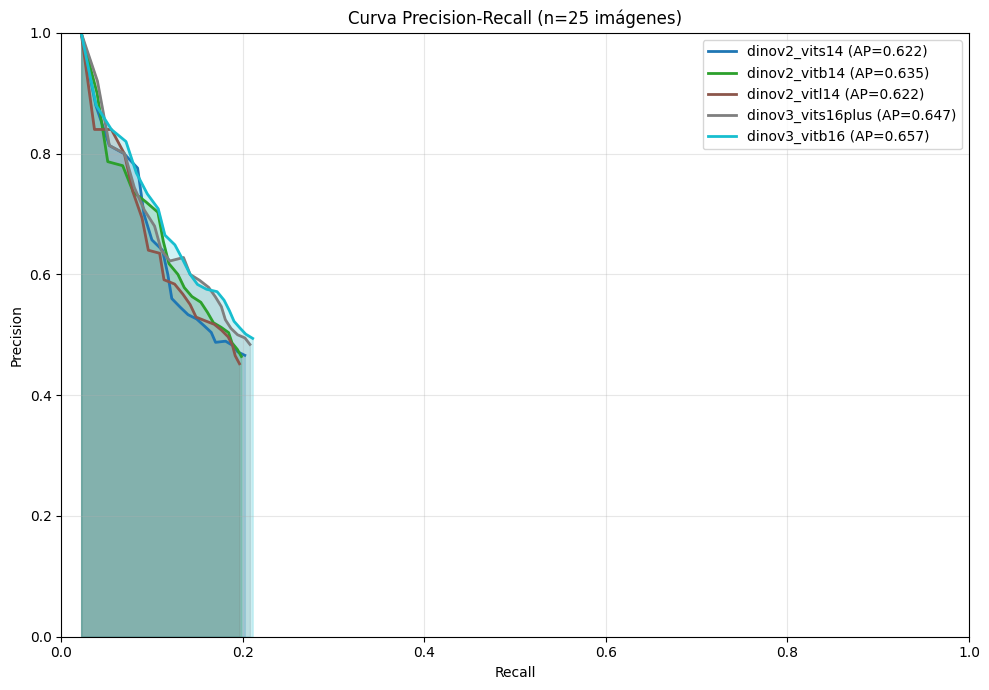

In [47]:
def simple_pr_plot(models_dict, df, valid_filenames, k=20):
    """
    Solución simple y robusta para el gráfico Precision-Recall.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))
    
    for color, (model_name, compute_fn) in zip(colors, models_dict.items()):
        aps = []
        all_recalls = []
        all_precisions = []
        
        # Muestrear algunas imágenes para evitar sobrecarga
        sample_indices = list(range(0, min(50, len(valid_filenames)), 2))
        
        for idx in sample_indices:
            try:
                ap, res = compute_fn(idx, k)
                if res and 'precisions' in res and 'recalls' in res:
                    aps.append(ap)
                    all_precisions.append(res['precisions'])
                    all_recalls.append(res['recalls'])
            except:
                continue
        
        if aps:
            # Promediar usando la longitud mínima
            min_len = min(len(p) for p in all_precisions)
            avg_precision = np.mean([p[:min_len] for p in all_precisions], axis=0)
            avg_recall = np.mean([r[:min_len] for r in all_recalls], axis=0)
            mean_ap = np.mean(aps)
            
            ax.plot(avg_recall, avg_precision, label=f'{model_name} (AP={mean_ap:.3f})', 
                   color=color, linewidth=2)
            ax.fill_between(avg_recall, avg_precision, alpha=0.2, color=color)
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Curva Precision-Recall (n={len(sample_indices)} imágenes)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usar la solución simple
simple_pr_plot(compute_functions, df, df['Title'].tolist(), k=20)